In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/placement.csv")

# Display first 5 rows
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [51]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()

Rows and Columns: (100000, 26)
Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  ob

In [52]:
# Check missing values
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.reset_defaults()

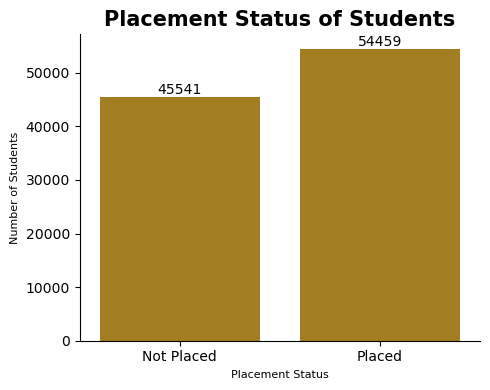

In [78]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df,
    x="placement_status",
    color="darkgoldenrod"
)

plt.title("Placement Status of Students", fontsize=15, fontweight="bold")
plt.xlabel("Placement Status", fontsize=8)
plt.ylabel("Number of Students", fontsize=8)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

### Observation
- The dataset contains both placed and not placed students.
- This indicates that the dataset is balanced enough for building a prediction model.

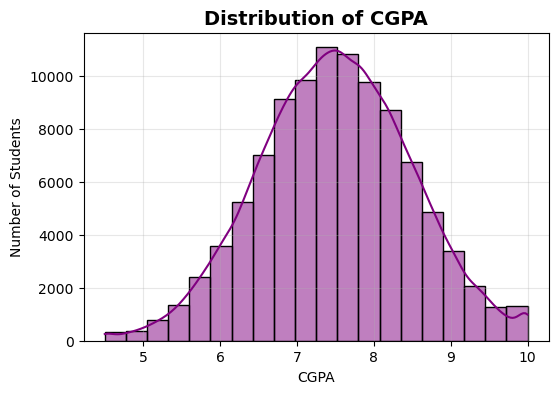

In [66]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="cgpa",
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Distribution of CGPA", fontsize=14, fontweight="bold")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.grid(alpha=0.3)

plt.show()

### Observation
- Most students have a CGPA between 7 and 9.
- Very few students have extremely low or extremely high CGPA values.

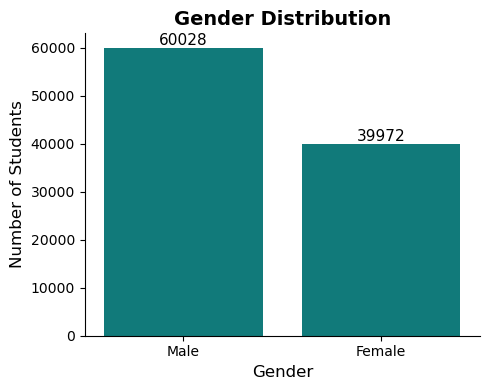

In [59]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df,
    x="gender",
    color="darkcyan"
)

plt.title("Gender Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Observation
- The dataset contains both male and female students.
- The gender distribution is fairly balanced.

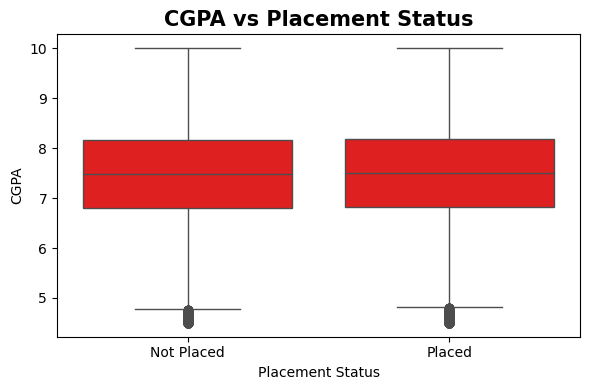

In [65]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="placement_status",
    y="cgpa",
    color="red"
)

plt.title("CGPA vs Placement Status", fontsize=15, fontweight="bold")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

plt.tight_layout()
plt.show()

### Observation
- Students with higher CGPA generally have a higher chance of getting placed.
- However, CGPA alone does not guarantee placement.

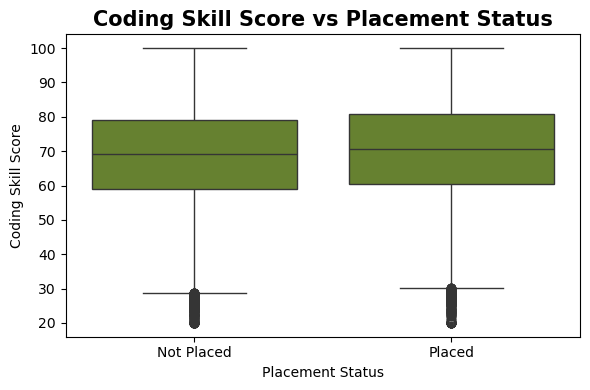

In [77]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="placement_status",
    y="coding_skill_score",
    color="olivedrab"
)

plt.title("Coding Skill Score vs Placement Status", fontsize=15, fontweight="bold")
plt.xlabel("Placement Status")
plt.ylabel("Coding Skill Score")

plt.tight_layout()
plt.show()

### Observation
- Placed students tend to have higher coding skill scores.
- Coding skills appear to play an important role in placement.

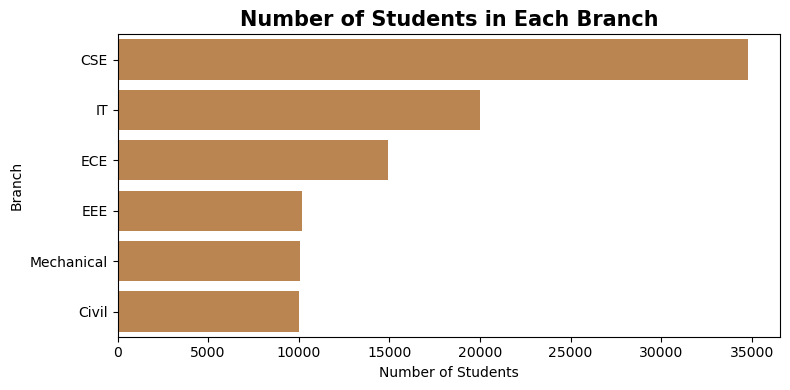

In [81]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    y="branch",
    color="peru",
    order=df["branch"].value_counts().index
)

plt.title("Number of Students in Each Branch", fontsize=15, fontweight="bold")
plt.xlabel("Number of Students")
plt.ylabel("Branch")

plt.tight_layout()
plt.show()

### Observation
- Students belong to multiple engineering branches.
- The number of students varies across branches.

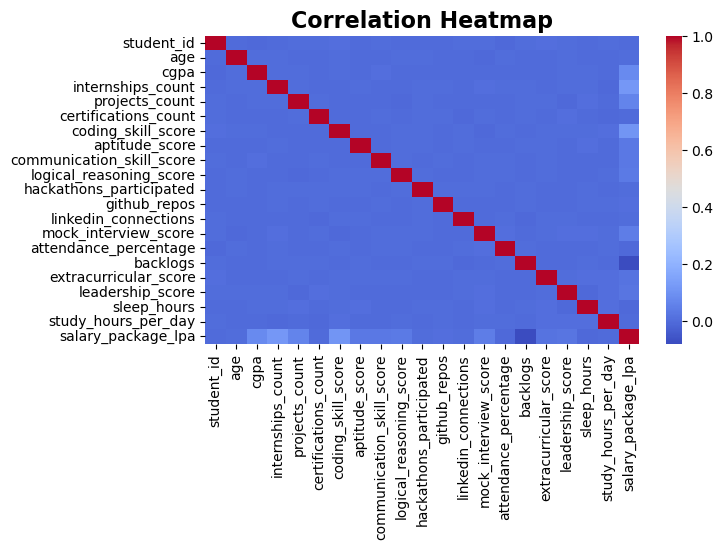

In [88]:
plt.figure(figsize=(7,4))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.show()

### Observation
- Some numerical features show positive correlation with placement-related factors.
- The heatmap helps identify which variables are most strongly related.

# Conclusion

This exploratory data analysis provided valuable insights into the student placement dataset. Features such as CGPA, coding skills, internships, and projects appear to have a significant influence on placement outcomes. The dataset contains no missing values and is well-suited for machine learning. These findings will help in building an accurate placement prediction model.